Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate Values:
 0

After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Accuracy Score:
0.8059701492537313

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



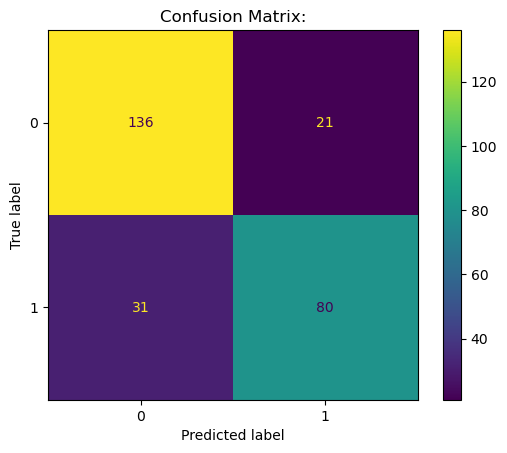

In [9]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,confusion_matrix

# Load Dataset
titanic_csv="C:\\Users\hp\\Downloads\\titanic.csv"
df = pd.read_csv(titanic_csv)

# ---------------- PREPROCESSING ----------------

# Missing Values
print("Missing Values:\n", df.isnull().sum())

# Duplicate Values
print("Duplicate Values:\n", df.duplicated().sum())

# Drop unwanted columns
df = df.drop(["Name", "Ticket", "Cabin"], axis=1, errors='ignore')

# Convert categorical columns
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

# Convert Embarked column
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode().iloc[0]
)

# Check after preprocessing
print("\nAfter Cleaning:\n")
print(df.isnull().sum())

# ---------------- FEATURES & TARGET ----------------

X = df.drop("Survived", axis=1)
y = df["Survived"]

# ---------------- TRAIN TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ---------------- MODEL ----------------

model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix:")
plt.show()